>>> Wczytano wektor kwantowy (Logistic L1) o kształcie (563, 15)

>>> Start optymalizacji Walk-Forward (Logistic Regression L1)...

--- WYNIKI LOGISTIC REGRESSION L1 ---
Accuracy: 0.4951 (Thresh = 0.50)
AUC ROC:  0.5077
Średnia liczba całkowicie wyzerowanych osi: 0 z 15

--- TOP 5 NAJSILNIEJSZYCH SYGNAŁÓW Z QPU ---
1. Q2_Y: Siła sygnału = 0.3472
2. Q0_X: Siła sygnału = 0.1717
3. Q3_X: Siła sygnału = 0.1678
4. Q0_Y: Siła sygnału = 0.1574
5. Q3_Z: Siła sygnału = 0.1149


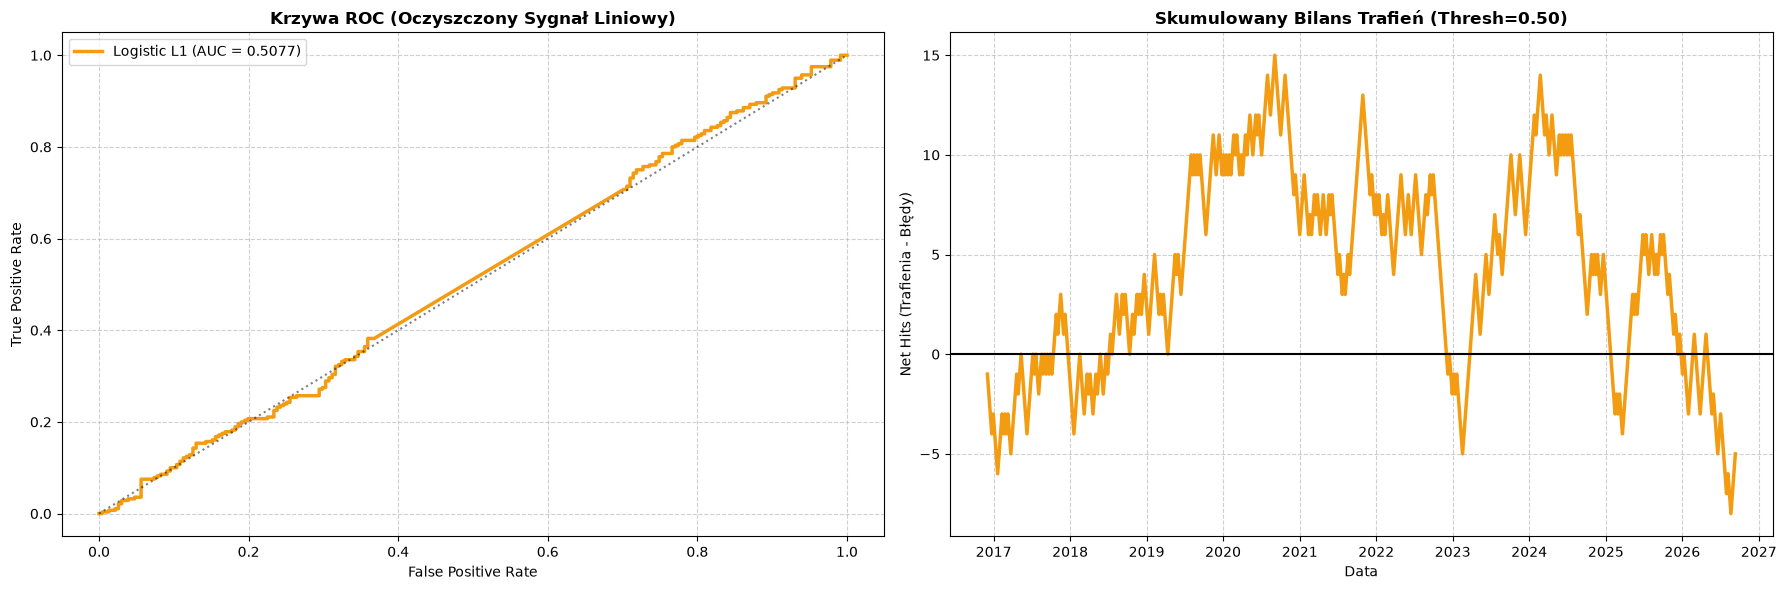

In [1]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA DANYCH
# ==========================================
PLIK_KACHE = "phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.npz" 
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
y = y_raw[LOOKBACK:]
dates = dates_raw[LOOKBACK:]

loaded_archive = np.load(PLIK_KACHE, allow_pickle=True)
first_key = loaded_archive.files[0]
Phi_real = loaded_archive[first_key]

print(f">>> Wczytano wektor kwantowy (Logistic L1) o kształcie {Phi_real.shape}")

FEATURE_NAMES = [
    "Q0_X", "Q0_Y", "Q0_Z",
    "Q1_X", "Q1_Y", "Q1_Z",
    "Q2_X", "Q2_Y", "Q2_Z",
    "Q3_X", "Q3_Y", "Q3_Z",
    "Q4_X", "Q4_Y", "Q4_Z"
]

# ==========================================
# 2. TRENOWANIE KROCZĄCE: REGRESJA LOGISTYCZNA (L1)
# ==========================================
print("\n>>> Start optymalizacji Walk-Forward (Logistic Regression L1)...")

TRAIN_WINDOW = 52
inner_cv = TimeSeriesSplit(n_splits=3)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=42))
])

# 'C' to odwrotność siły regularyzacji (mniejsze C = silniejsze cięcie szumu)
param_grid = {
    "lr__C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
}

results = {"y_true": [], "dates": [], "prob": []}
coefs_history = []

for t in range(TRAIN_WINDOW, len(y)):
    X_tr, X_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_tr, y_tr)
    
    results["prob"].append(search.predict_proba(X_te)[0, 1])
    
    # Zapisujemy wagi z najlepszego modelu, by sprawdzić które kubity przetrwały cięcie L1
    best_lr = search.best_estimator_.named_steps["lr"]
    coefs_history.append(best_lr.coef_[0])

y_true = np.array(results["y_true"])
prob_preds = np.array(results["prob"])

final_preds = (prob_preds > 0.50).astype(int)
acc = accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, prob_preds)

# ==========================================
# 3. ANALIZA PRZETRWANIA CECH
# ==========================================
avg_coefs = np.abs(np.mean(coefs_history, axis=0))
zeroed_out = np.sum(avg_coefs == 0.0)

print(f"\n--- WYNIKI LOGISTIC REGRESSION L1 ---")
print(f"Accuracy: {acc:.4f} (Thresh = 0.50)")
print(f"AUC ROC:  {auc:.4f}")
print(f"Średnia liczba całkowicie wyzerowanych osi: {zeroed_out} z 15")

sorted_idx = np.argsort(avg_coefs)[::-1]
print("\n--- TOP 5 NAJSILNIEJSZYCH SYGNAŁÓW Z QPU ---")
for i in range(5):
    print(f"{i+1}. {FEATURE_NAMES[sorted_idx[i]]}: Siła sygnału = {avg_coefs[sorted_idx[i]]:.4f}")

# ==========================================
# 4. WIZUALIZACJA
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fpr, tpr, _ = roc_curve(y_true, prob_preds)
ax[0].plot(fpr, tpr, color='#f39c12', lw=2.5, label=f'Logistic L1 (AUC = {auc:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC (Oczyszczony Sygnał Liniowy)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

net_hits = np.cumsum(np.where(final_preds == y_true, 1, -1))
ax[1].plot(results["dates"], net_hits, color='#f39c12', lw=2.5)
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Thresh=0.50)', fontweight='bold')
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()